# Data Analysis and Cleaning - Introduction

Before we start, we take a look at the dataset:

In [8]:
!head data/iris_dirty.csv 

Der Befehl "head" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('data/iris_dirty.csv',
                 header=None,
                 encoding='iso-8859-15',
                 names=['sepal length', 'sepal width', 'petal length', 'petal width', 'class'])

In [5]:
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,2 mm,Iris-setosa
1,4.9,3.0,1.4,2 mm,Iris-setosa
2,4.7,3.2,1.3,2 mm,Iris-setosa
3,4.6,3.1,1.5,2 mm,Iris-setosa
4,5.0,3.6,1.4,2 mm,Iris-setosa


In [9]:
df.count()

sepal length    151
sepal width     150
petal length    151
petal width     151
class           151
dtype: int64

There is missing data and we have to correct it:

In [10]:
df['sepal width']

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
146    3.0
147    2.5
148    3.0
149    3.4
150    3.0
Name: sepal width, Length: 151, dtype: float64

In [11]:
df['sepal width'].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
146    False
147    False
148    False
149    False
150    False
Name: sepal width, Length: 151, dtype: bool

In [12]:
df[df['sepal width'].isnull()]

,sepal length,sepal width,petal length,petal width,class
82,5.8,NaN,3.9,12 mm,Iris-versicolor


In [13]:
iris_versicolor = df[df['class']  == 'Iris-versicolor']

iris_versicolor

,sepal length,sepal width,petal length,petal width,class
50,7.0,3.2,4.7,14 mm,Iris-versicolor
51,6.4,3.2,4.5,15 mm,Iris-versicolor
52,6.9,3.1,4.9,15 mm,Iris-versicolor
53,5.5,2.3,4.0,13 mm,Iris-versicolor
54,6.5,2.8,4.6,15 mm,Iris-versicolor
55,5.7,2.8,4.5,13 mm,Iris-versicolor
56,6.3,3.3,4.7,16 mm,Iris-versicolor
57,4.9,2.4,3.3,10 mm,Iris-versicolor
58,6.6,2.9,4.6,13 mm,Iris-versicolor
59,5.2,2.7,3.9,14 mm,Iris-versicolor


In [14]:
iris_versicolor_sepal_width = iris_versicolor['sepal width']

iris_versicolor_sepal_width

50     3.2
51     3.2
52     3.1
53     2.3
54     2.8
55     2.8
56     3.3
57     2.4
58     2.9
59     2.7
60     2.0
61     3.0
62     2.2
63     2.9
64     2.9
65     3.1
66     3.0
67     2.7
68     2.2
69     2.5
70     3.2
71     2.8
72     2.5
73     2.8
74     2.9
75     3.0
76     2.8
77     3.0
78     2.9
79     2.6
80     2.4
81     2.4
82     NaN
83     2.7
84     3.0
85     3.4
86     3.1
87     2.3
88     3.0
89     2.5
90     2.6
91     3.0
92     2.6
93     2.3
94     2.7
95     3.0
96     2.9
97     2.9
98     2.5
99     2.8
100    3.2
Name: sepal width, dtype: float64

In [18]:
mean_sepal_width = pd.Series.mean(iris_versicolor_sepal_width)

mean_sepal_width

2.78

In [19]:
df.loc[82]

sepal length                5.8
sepal width                 NaN
petal length                3.9
petal width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

In [21]:
df.loc[82, 'sepal width'] = mean_sepal_width
# verwendet den Durchschnittswert als substitude für den fehlenden Wert, es gibt unterschiedliche Methoden und herangehensweisen für dieses Problem, dies ist nur eine Möglichkeit

df.loc[82]

sepal length                5.8
sepal width                2.78
petal length                3.9
petal width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

In [22]:
df.count()

sepal length    151
sepal width     151
petal length    151
petal width     151
class           151
dtype: int64

Check the data for duplicates and remove the duplicates if necessary:

In [1]:
df[df.duplicated(keep=False)]
# löscht duplikate automatisch aus den Daten, ist nicht immer sinnvoll, kommt auf den UseCase an

NameError: name 'df' is not defined

In [28]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


In [27]:
df = df.drop(df.index[[100]])
# random datensatz der classe versicolor wurde gelöscht, damit alle drei klassen die gleiche anzahl an datensätze haben

In [29]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Are there typos that we need to fix:

In [30]:
df[df['class']  == 'Iris-setsoa']

,sepal length,sepal width,petal length,petal width,class
49,5.0,3.3,1.4,2 mm,Iris-setsoa


In [31]:
df.loc[49,'class'] = 'Iris-setosa'

In [32]:
df.groupby('class').count()

,sepal length,sepal width,petal length,petal width
class,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


Are all formats uniform?

In [33]:
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,2 mm,Iris-setosa
1,4.9,3.0,1.4,2 mm,Iris-setosa
2,4.7,3.2,1.3,2 mm,Iris-setosa
3,4.6,3.1,1.5,2 mm,Iris-setosa
4,5.0,3.6,1.4,2 mm,Iris-setosa


In [34]:
pd.to_numeric('2 mm'.replace(' mm', '')) / 10

0.2

In [35]:
def convert_from_mm(row):
    return pd.to_numeric(row['petal width'].replace(' mm', '')) / 10

In [36]:
df['petal width'] = df.apply(convert_from_mm, axis='columns')

In [37]:
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Let's check the data for outliers:

In [39]:
df.describe()
#std ist standardabweichung, hohe zahl gleich unregelmäßige daten, möglicherweise fehler, maximalwert ist 58, durchschnitt ist aber 6.19, hier ist womöglich der Ursprung
#vom Fehler

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,6.191333,3.054533,3.758667,1.198667
std,4.338310,0.433205,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,58.000000,4.400000,6.900000,2.500000


In [42]:
df.groupby('class').describe()
#iris virginica hat den höchsten standardabweichung, vermutlich befindet sich hier der fehlerhafte datensatz von sepal length

sepal length                                              \
                       count   mean       std  min  25%  50%   75%   max   
class                                                                      
Iris-setosa             50.0  5.006  0.352490  4.3  4.8  5.0  5.20   5.8   
Iris-versicolor         50.0  5.936  0.516171  4.9  5.6  5.9  6.30   7.0   
Iris-virginica          50.0  7.632  7.295356  4.9  6.3  6.5  7.05  58.0   

                sepal width          ... petal length      petal width         \
                      count    mean  ...          75%  max       count   mean   
class                                ...                                        
Iris-setosa            50.0  3.4180  ...        1.575  1.9        50.0  0.244   
Iris-versicolor        50.0  2.7716  ...        4.600  5.1        50.0  1.326   
Iris-virginica         50.0  2.9740  ...        5.875  6.9        50.0  2.026   

                                                    
                      std  min  25%  50%  75%  max  
class                                               
Iris-setosa      0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

In [43]:
import matplotlib.pyplot as plt

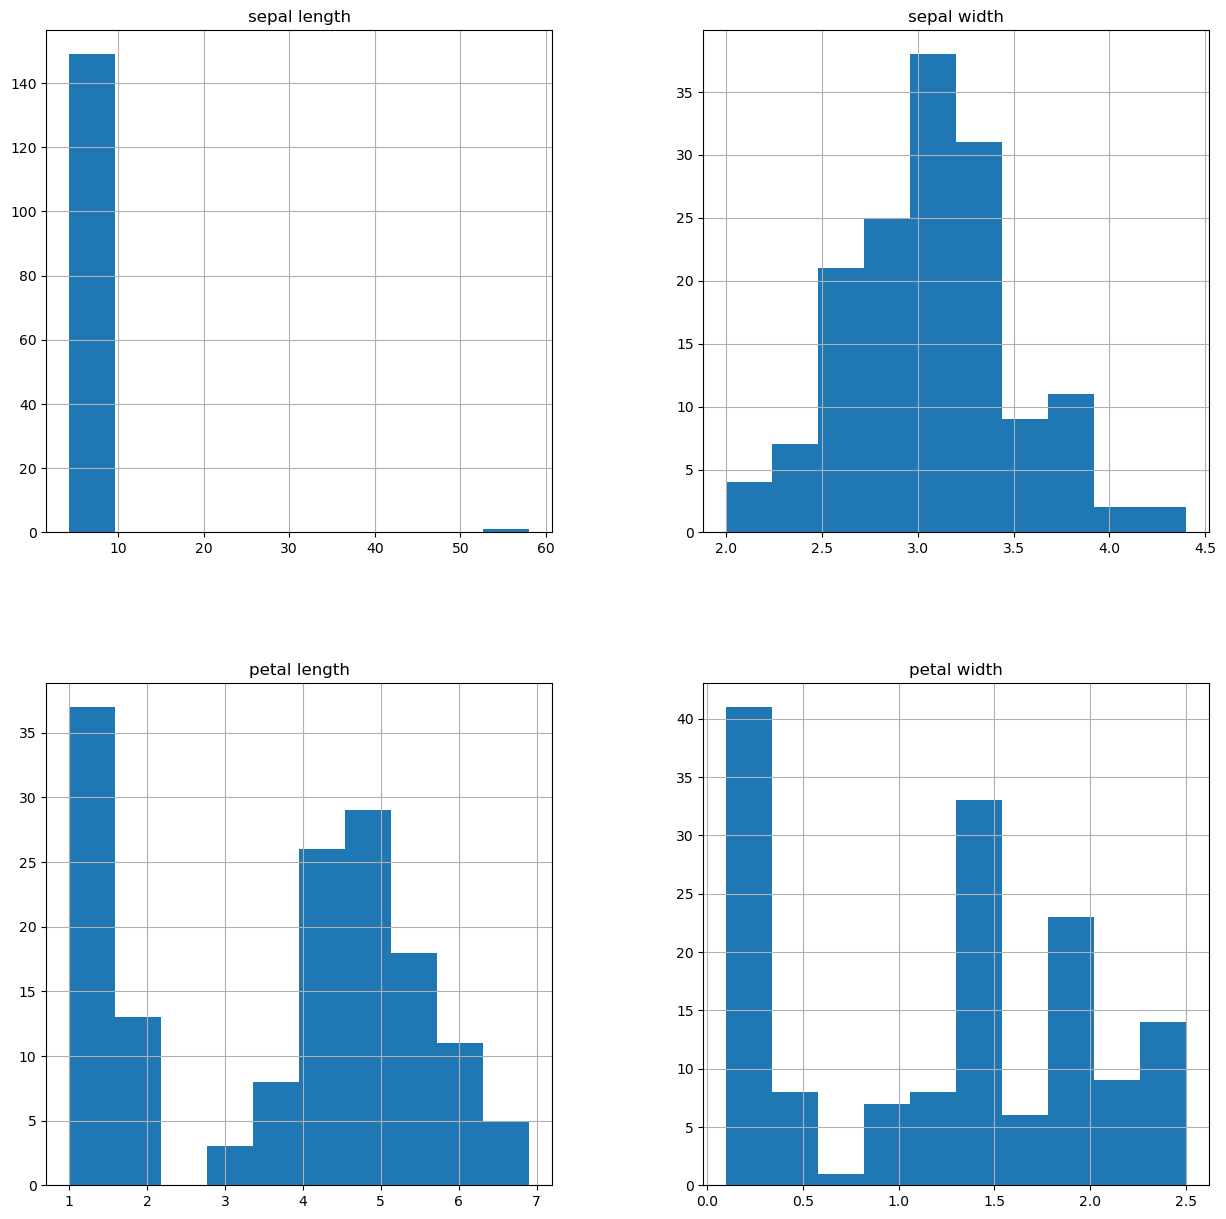

In [44]:
df.hist(figsize=(15, 15))
plt.show()
# sepal length zeigt hier eindeutig die existenz vom ausreißer

In [51]:
df[df['sepal length'] > 50]

,sepal length,sepal width,petal length,petal width,class
143,58.0,2.7,5.1,1.9,Iris-virginica


In [55]:
import seaborn as sns

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


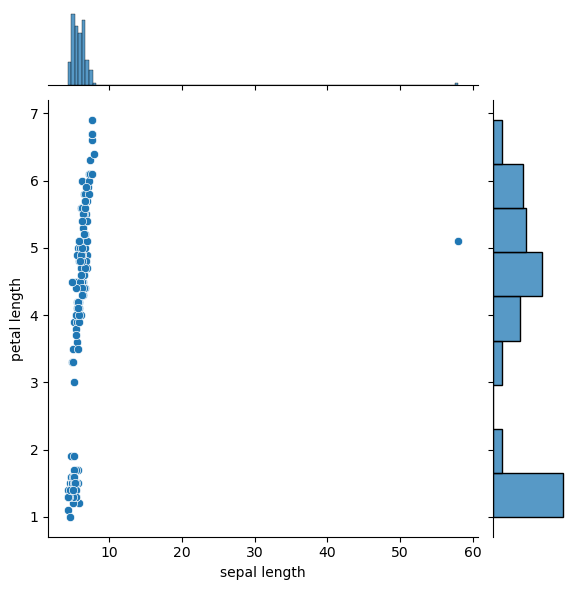

In [56]:
sns.jointplot(x=df['sepal length'], y=df['petal length'])
plt.show()

In [59]:
df.loc[143, 'sepal length'] = 5.8
#der falsche wert wurde richtig gestellt

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


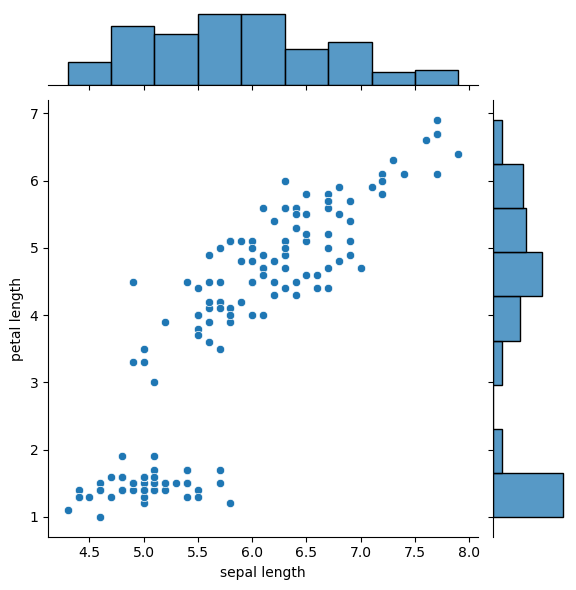

In [58]:
# p value:
# https://en.wikipedia.org/wiki/P-value
# http://www.dummies.com/education/math/statistics/what-a-p-value-tells-you-about-statistical-data/
# https://xkcd.com/1478/

sns.jointplot(x=df['sepal length'], y=df['petal length'])
plt.show()

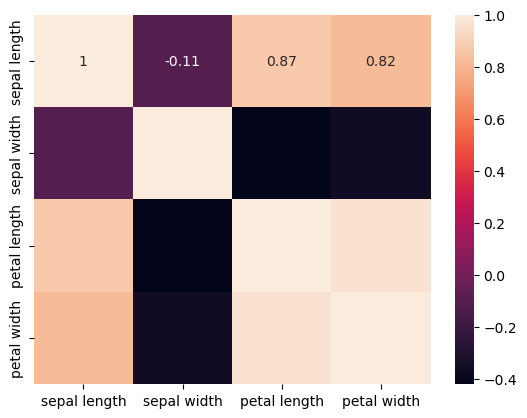

In [61]:
# https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

corrmat = df.corr(numeric_only=True)
sns.heatmap(corrmat, annot=True)
plt.show()

In [37]:
# save the cleaned data

#df.to_csv('iris_cleaned.csv', index=False, header=True)

Bonus: Here are some additional visualizations:

Iris-setosa             Axes(0.1,0.559091;0.363636x0.340909)
Iris-versicolor    Axes(0.536364,0.559091;0.363636x0.340909)
Iris-virginica              Axes(0.1,0.15;0.363636x0.340909)
dtype: object

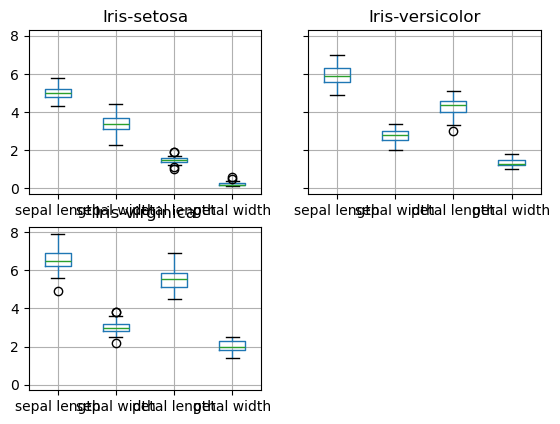

In [62]:
df.groupby('class').boxplot()

class
Iris-setosa        Axes(0.125,0.11;0.775x0.77)
Iris-versicolor    Axes(0.125,0.11;0.775x0.77)
Iris-virginica     Axes(0.125,0.11;0.775x0.77)
dtype: object

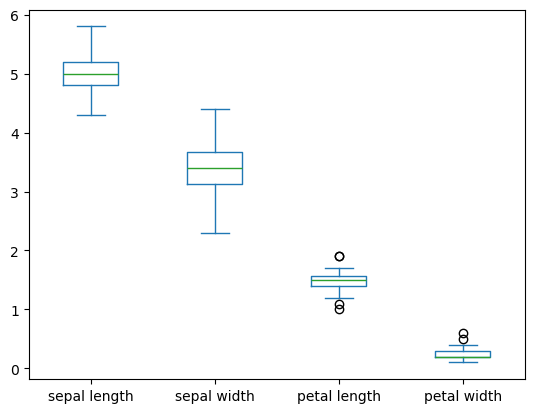

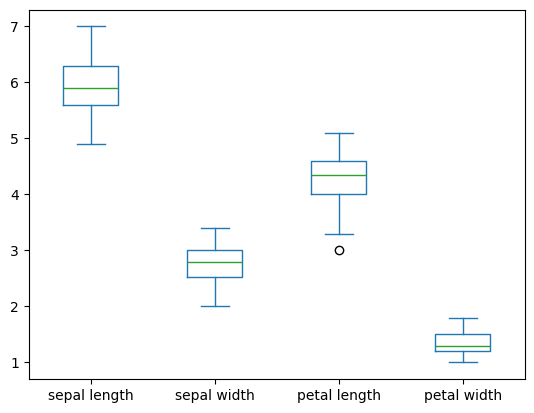

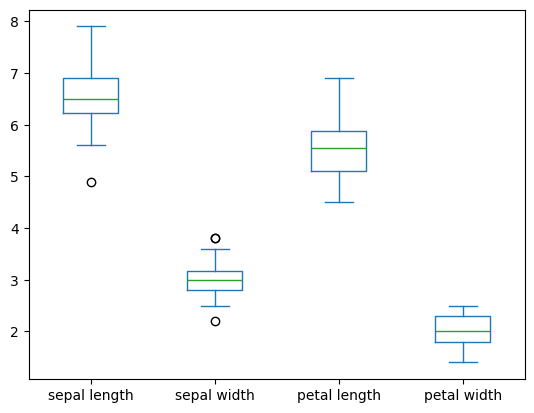

In [63]:
df.groupby('class').plot.box()

<Axes: >

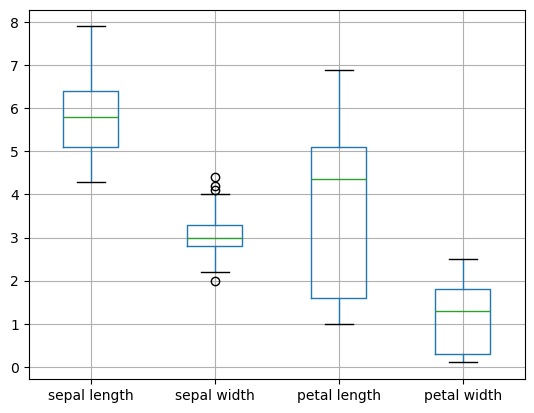

In [64]:
df.boxplot()

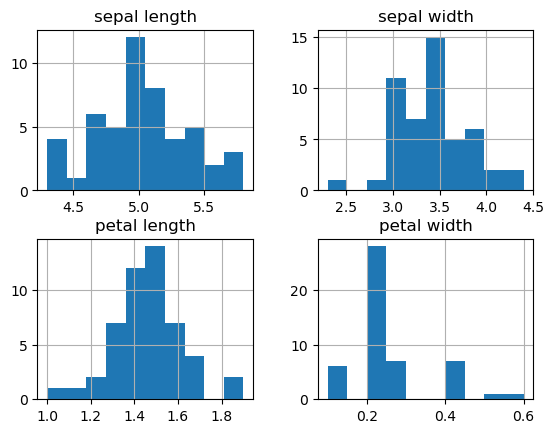

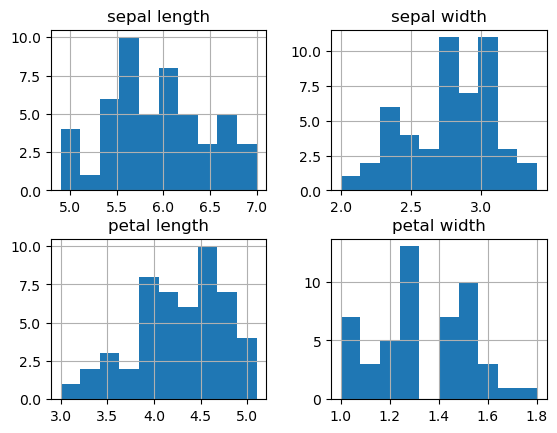

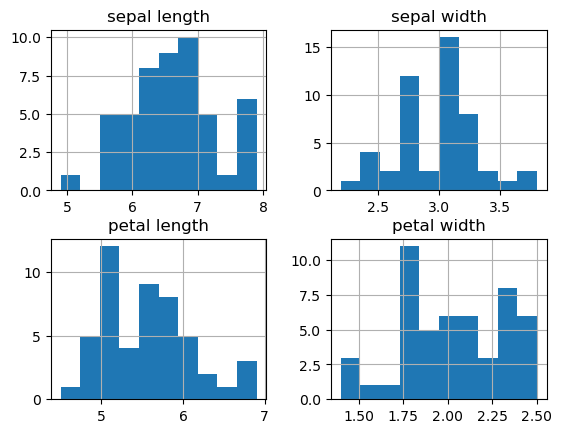

In [65]:
df.groupby('class').hist()
plt.show()

class
Iris-setosa        Axes(0.125,0.11;0.775x0.77)
Iris-versicolor    Axes(0.125,0.11;0.775x0.77)
Iris-virginica     Axes(0.125,0.11;0.775x0.77)
Name: sepal length, dtype: object

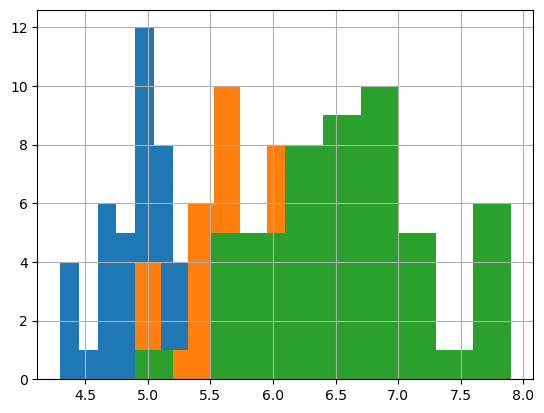

In [66]:
df.groupby('class')['sepal length'].hist()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

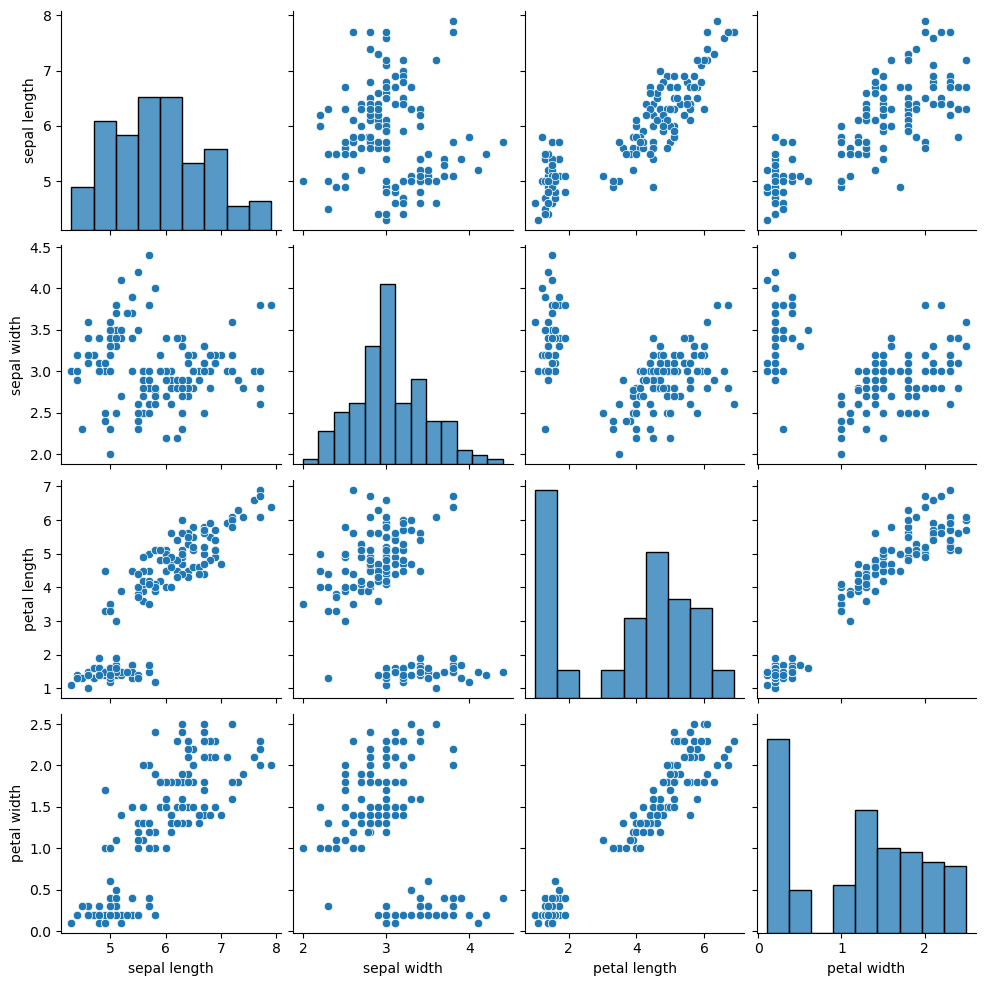

In [67]:
sns.pairplot(df, kind="scatter")

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

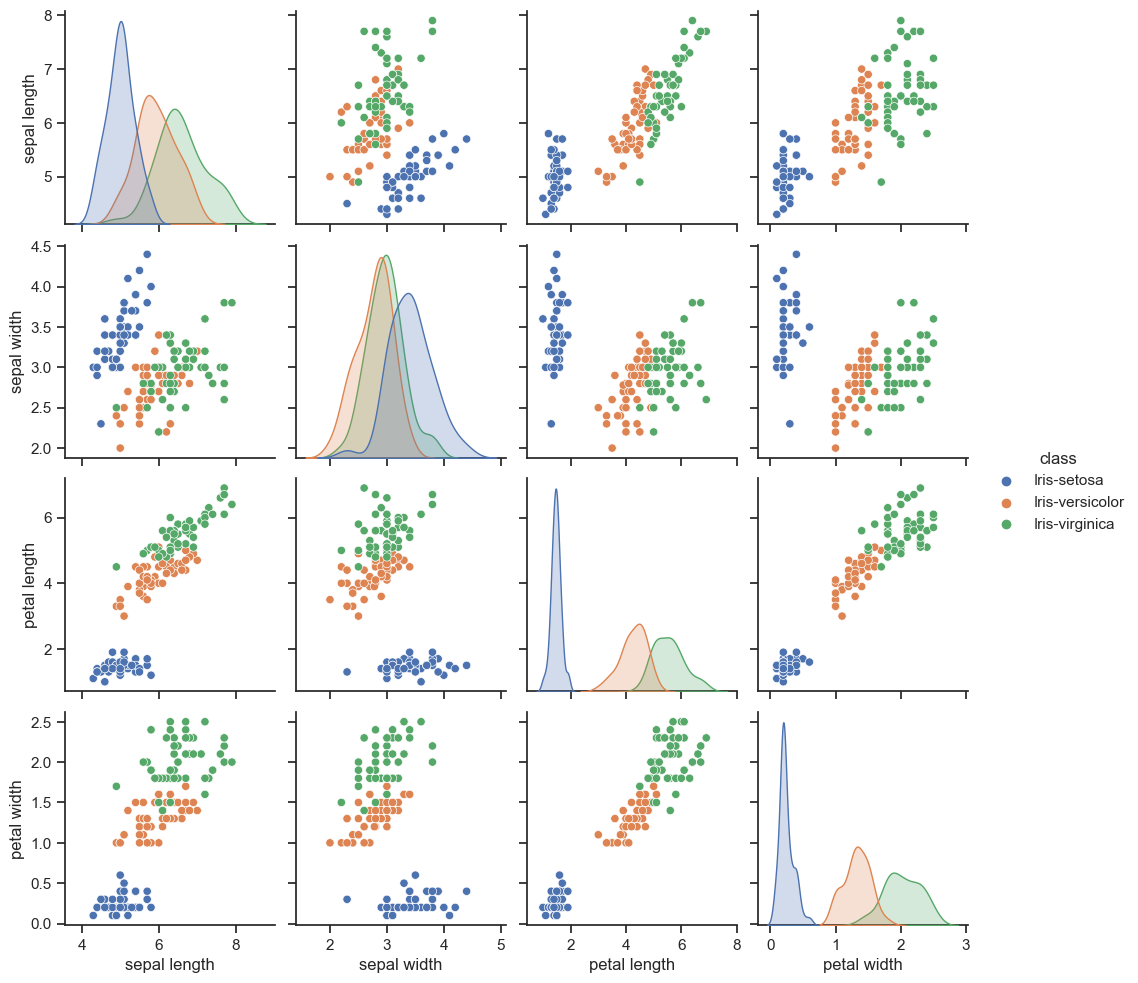

In [68]:
sns.set(style="ticks")
sns.pairplot(df, hue="class")